# Football Analysis
## Exercise 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
print('✅ Libraries imported!')

✅ Libraries imported!


## Load Data

In [2]:
df = pd.read_csv('../data/results.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## Q1-Q4: Basic Exploration

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
print(f'1. Total: {len(df):,}')
print(f'2. Years: {df["year"].min()}-{df["year"].max()}')
print(f'3. Countries: {pd.concat([df["home_team"],df["away_team"]]).nunique()}')
print(f'4. Top home: {df["home_team"].value_counts().index[0]}')

1. Total: 49,287
2. Years: 1872-2026
3. Countries: 333
4. Top home: Brazil


## Q5-Q8: Goals

In [4]:
df['total_goals'] = df['home_score'] + df['away_score']
print(f'5. Avg: {df["total_goals"].mean():.2f}')
print(f'6. Max: {df["total_goals"].max()}')
print(f'7. Home: {df["home_score"].mean():.2f}, Away: {df["away_score"].mean():.2f}')
print(f'8. Common: {df["total_goals"].value_counts().idxmax()}')

5. Avg: 2.94
6. Max: 31.0
7. Home: 1.76, Away: 1.18
8. Common: 2.0


## Q9-Q11: Results

In [5]:
def result(row):
    if row['home_score']>row['away_score']: return 'Home Win'
    elif row['home_score']<row['away_score']: return 'Away Win'
    else: return 'Draw'
df['result'] = df.apply(result, axis=1)
pct = df['result'].value_counts(normalize=True)*100
print(f'9. Home: {pct["Home Win"]:.1f}%')
print(f'10. Advantage: {"YES" if pct["Home Win"]>pct["Away Win"] else "NO"}')
hw = df[df['result']=='Home Win']['home_team'].value_counts()
aw = df[df['result']=='Away Win']['away_team'].value_counts()
tw = hw.add(aw,fill_value=0).sort_values(ascending=False)
print(f'11. Most wins: {tw.index[0]} ({int(tw.iloc[0])})')

9. Home: 48.9%
10. Advantage: YES
11. Most wins: Brazil (670)


## Visualizations

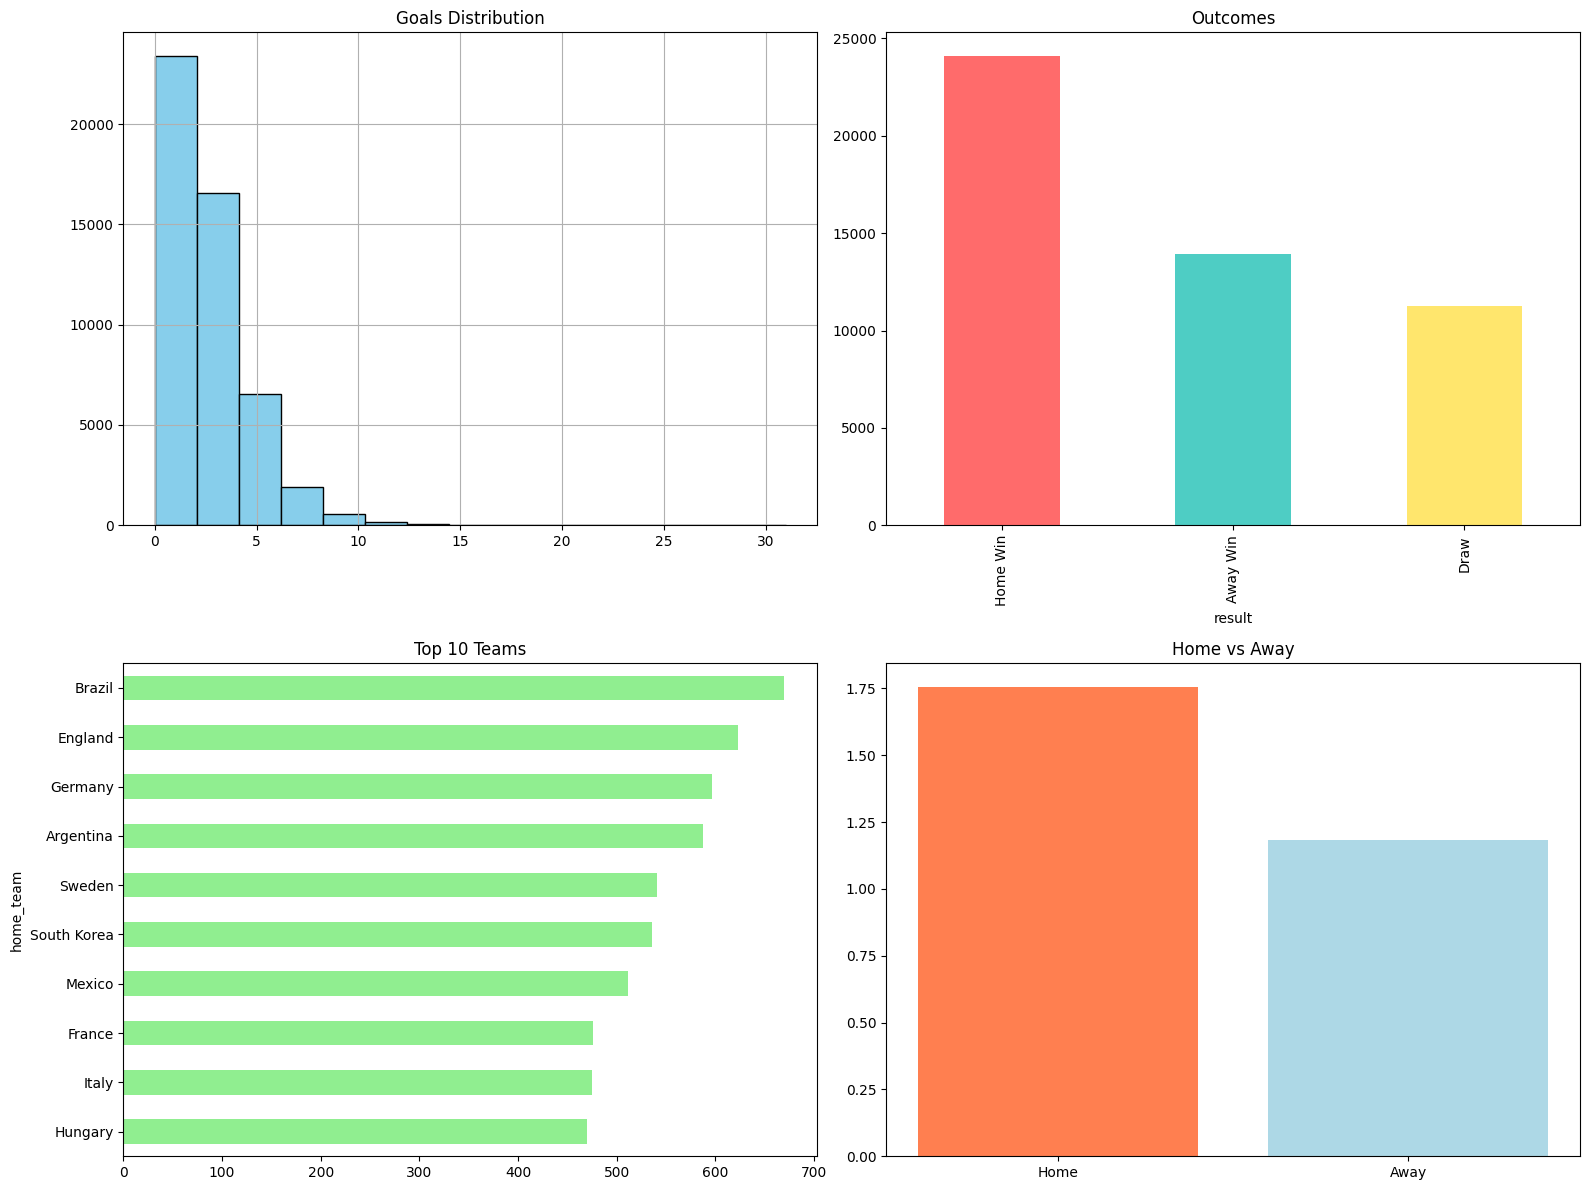

In [6]:
fig, ax = plt.subplots(2,2,figsize=(16,12))
df['total_goals'].hist(bins=15,ax=ax[0,0],color='skyblue',edgecolor='black')
ax[0,0].set_title('Goals Distribution')
df['result'].value_counts().plot(kind='bar',ax=ax[0,1],color=['#ff6b6b','#4ecdc4','#ffe66d'])
ax[0,1].set_title('Outcomes')
tw.head(10).sort_values().plot(kind='barh',ax=ax[1,0],color='lightgreen')
ax[1,0].set_title('Top 10 Teams')
ax[1,1].bar(['Home','Away'],[df['home_score'].mean(),df['away_score'].mean()],color=['coral','lightblue'])
ax[1,1].set_title('Home vs Away')
plt.tight_layout()
plt.savefig('../football_charts.png',dpi=300)
plt.show()